In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

c:\Users\hieno\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df.job_posted_date = pd.to_datetime(df.job_posted_date)
df.job_skills = df.job_skills.apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## 🟩 Data Scientist Hourly Salaries (2.17.1) - Problem

Create a histogram to show the distribution of hourly salaries (use salary_hour_avg column) for Data Scientist job postings:

* Create a new DataFrame called df_DS to filter out 'Data Scientist' jobs.
* Customize the plot by setting the number of bins to 40 and the bar color to blue.
* Label the x-axis as 'Hourly Salary' and the y-axis as 'Number of Jobs'.

In [4]:
df_DS = df.copy()[df['job_title_short'] == 'Data Scientist']
df_DS = df_DS.dropna(subset='salary_hour_avg')

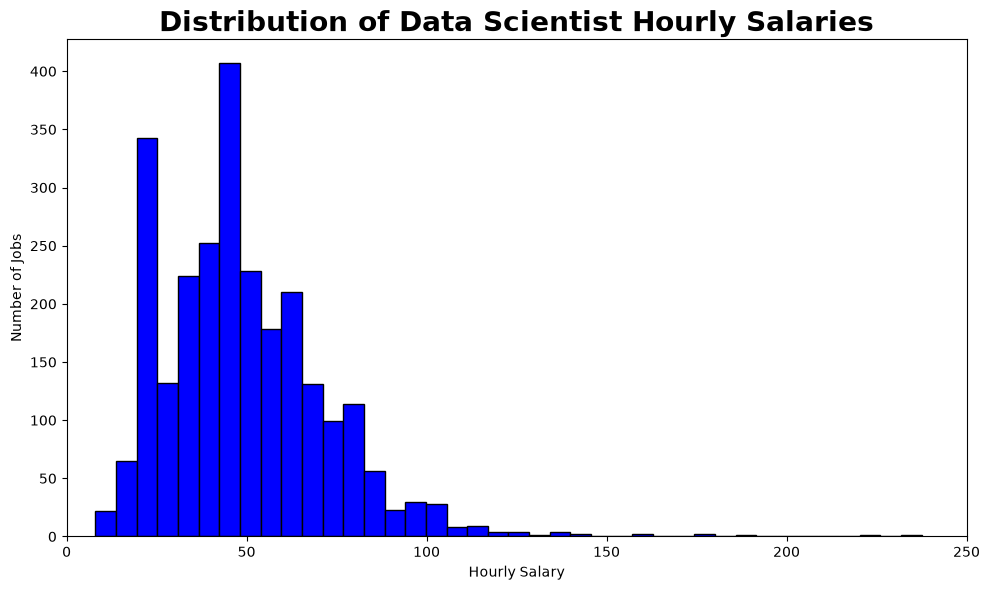

In [5]:
df_DS['salary_hour_avg'].plot(
                            kind='hist'
                            , bins = 40
                            , edgecolor = 'black'
                            , figsize = (10, 6)
                            , color = 'blue')

plt.title(
            'Distribution of Data Scientist Hourly Salaries'
            , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.xlabel(
            'Hourly Salary'
            , fontdict={'fontsize': 10})

plt.ylabel('Number of Jobs'
            , fontdict={'fontsize': 10})

plt.xlim(0, 250)
plt.tight_layout()
plt.show()

## 🟨 Job Postings by Number of Skills (2.17.2) - Problem

Create a histogram to show the distribution of job postings by the number of skills listed using the job_skills column:

* Create a new DataFrame called df_skills to filter out job postings with non-null job_skills.
* Customize the plot by setting the number of bins to 55, the bar color to 'magenta'
* Add a title 'Distribution of Job Postings by Number of Skills Listed'.
* Label the x-axis as 'Number of Skills' and the y-axis as 'Number of Job Postings'.

In [6]:
df_skills = df.copy()[df['job_skills'].notna()]

In [7]:
df_skills['num_skills'] = df_skills['job_skills'].apply(len)

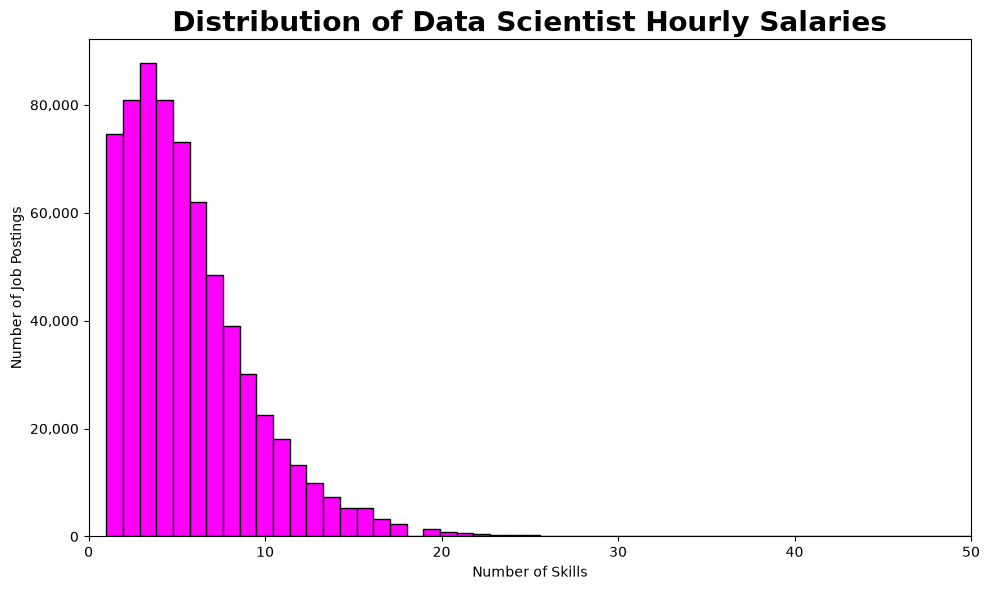

In [8]:
df_skills['num_skills'].plot(
                            kind = 'hist'
                            , bins = 55
                            , edgecolor = 'black'
                            , figsize = (10, 6)
                            , color = 'magenta')

plt.title(
            'Distribution of Data Scientist Hourly Salaries'
            , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.xlabel(
            'Number of Skills'
            , fontdict={'fontsize': 10})

plt.ylabel('Number of Job Postings'
            , fontdict={'fontsize': 10})

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'{int(y):,}'))

plt.xlim(0, 50)
plt.tight_layout()
plt.show()

## 🟥 Data Engineer Salaries (2.17.3) - Problem

Create a histogram to show the distribution of average yearly salaries (salary_year_avg) for Data Engineer job postings:

* Create a new DataFrame called df_DE to filter out 'Data Engineer' jobs.
* Customize the plot by setting the number of bins to 50, the bar color to red
* Add annotations for the mean and median salaries, using plt.axvline(); for the parameters specify:
  * color: 'blue'/'green'
  * linestyle: 'dashed'
  * label: e.g., f'Mean: ${mean_salary:,.0f}'
* Label the x-axis as 'Yearly Salary' and the y-axis as 'Number of Jobs'.

In [9]:
df_DE = df.copy()[df['job_title_short'] == 'Data Engineer']
df_DE = df_DE.dropna(subset='salary_year_avg')

In [10]:
DE_mean_salary = df_DE['salary_year_avg'].mean()
DE_median_salary = df_DE['salary_year_avg'].median()

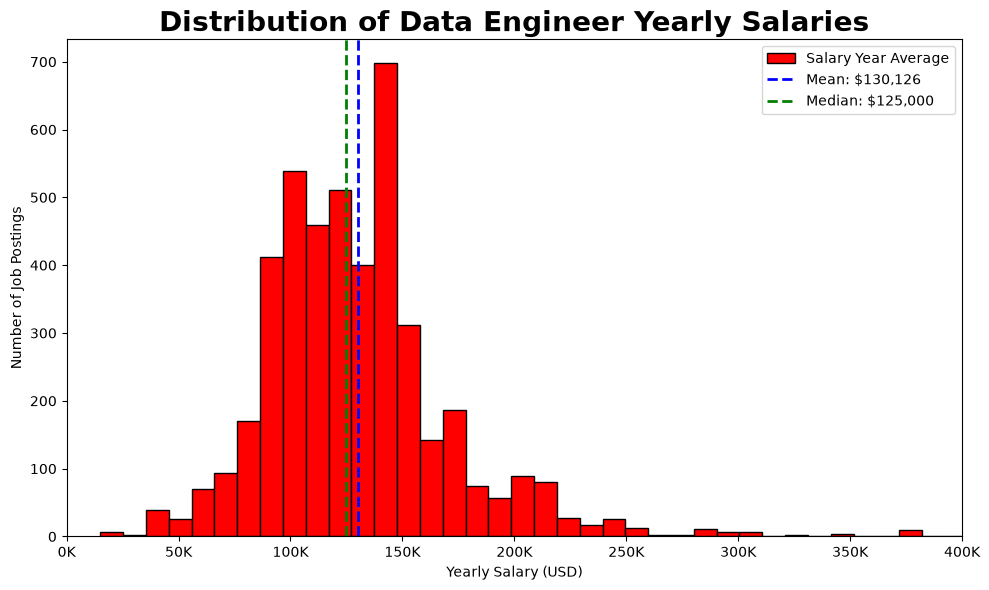

In [11]:
df_DE['salary_year_avg'].plot(
                            kind='hist'
                            , bins = 50
                            , color = 'red'
                            , edgecolor = 'black'
                            , figsize=(10, 6)
                            , label = 'Salary Year Average')

plt.axvline(
            x = DE_mean_salary
            , color = 'blue'
            , linewidth = 2
            , linestyle = '--'
            , label = f'Mean: ${DE_mean_salary:,.0f}'
            )

plt.axvline(
            x = DE_median_salary
            , color = 'green'
            , linewidth = 2
            , linestyle = '--'
            , label = f'Median: ${DE_median_salary:,.0f}'
            )

plt.title(
            'Distribution of Data Engineer Yearly Salaries'
            , fontdict={'fontsize': 20, 'fontweight': 'bold'})

plt.xlabel(
            'Yearly Salary (USD)'
            , fontdict={'fontsize': 10})

plt.ylabel('Number of Job Postings'
            , fontdict={'fontsize': 10})

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x/1000):,}K'))

plt.legend()
plt.xlim(0, 400000)
plt.tight_layout()
plt.show()